In [8]:
import pandas as pd
from scipy.stats import kruskal
import numpy as np
import matplotlib.pyplot as plt

# Read the CSV file
df_raw = pd.read_csv('shipment.csv')

df_raw.columns = df_raw.columns.str.strip()

date_col = 'date'
port_col = 'portid'
numerical_features = ['import', 'export', 'portcalls']

df = df_raw.dropna(subset = [date_col, port_col] + numerical_features).copy()
df[date_col] = pd.to_datetime(df[date_col])

initial_count = df.shape[0]
df = df.groupby([date_col, port_col])[numerical_features].sum().reset_index()
final_count = df.shape[0]

df['import'] = pd.to_numeric(df['import'], errors='coerce')
df['export'] = pd.to_numeric(df['export'], errors='coerce')

# Drop rows where cargo values are NaN after conversion, if any
df.dropna(subset=['import', 'export'], inplace=True)

# Print summary metrics of your ingested dataset
print(f"Successfully loaded {initial_count} raw operational rows.")
print(f"Aggregated into {final_count} unique daily port sequences (Combined {initial_count - final_count} duplicate rows).")
print(f"Unique Ports Detected: {df[port_col].nunique()}")
print(f"Timeline Window : {df[date_col].min().strftime('%Y-%m-%d')} to {df[date_col].max().strftime('%Y-%m-%d')}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Successfully loaded 108746 raw operational rows.
Aggregated into 68900 unique daily port sequences (Combined 39846 duplicate rows).
Unique Ports Detected: 26
Timeline Window : 2019-01-01 to 2026-04-03


,date,portid,import,export,portcalls
0,2019-01-01 00:00:00+00:00,fso152,0.000000,0.000000,0.0
1,2019-01-01 00:00:00+00:00,port1056,0.000000,0.000000,0.0
2,2019-01-01 00:00:00+00:00,port1232,0.000000,0.000000,0.0
3,2019-01-01 00:00:00+00:00,port1238,0.000000,0.000000,1.0
4,2019-01-01 00:00:00+00:00,port125,5498.181383,86.655175,10.0


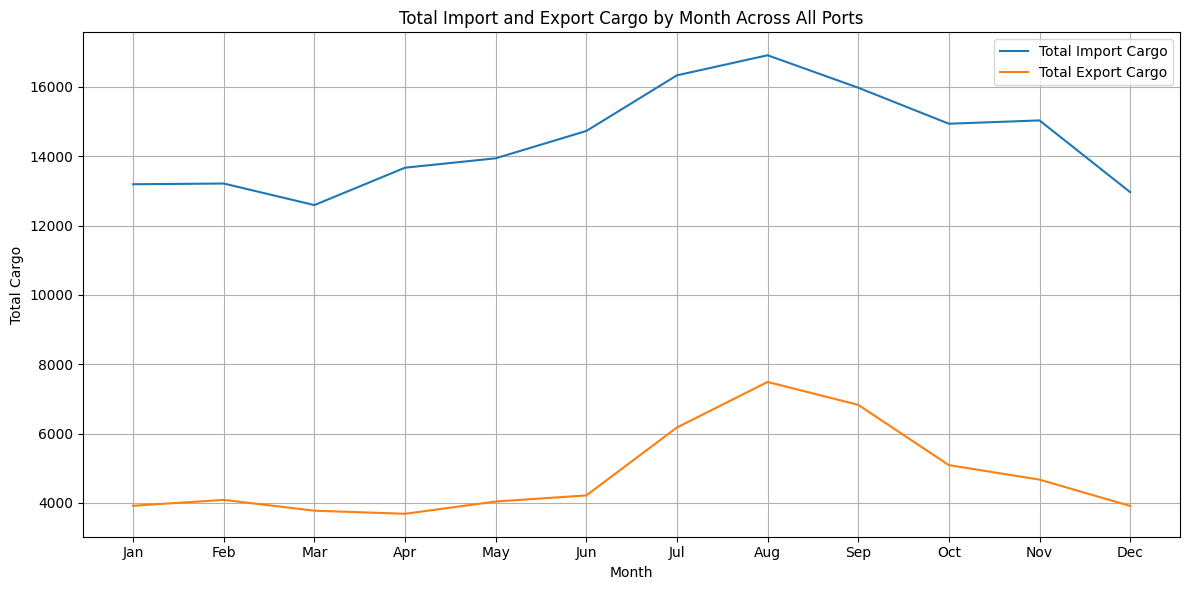

In [9]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

monthly_traffic = df.groupby('month')[['import', 'export']].mean().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(monthly_traffic['month'], monthly_traffic['import'], label='Total Import Cargo')
plt.plot(monthly_traffic['month'], monthly_traffic['export'], label='Total Export Cargo')
plt.title('Total Import and Export Cargo by Month Across All Ports')
plt.xlabel('Month')
plt.ylabel('Total Cargo')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

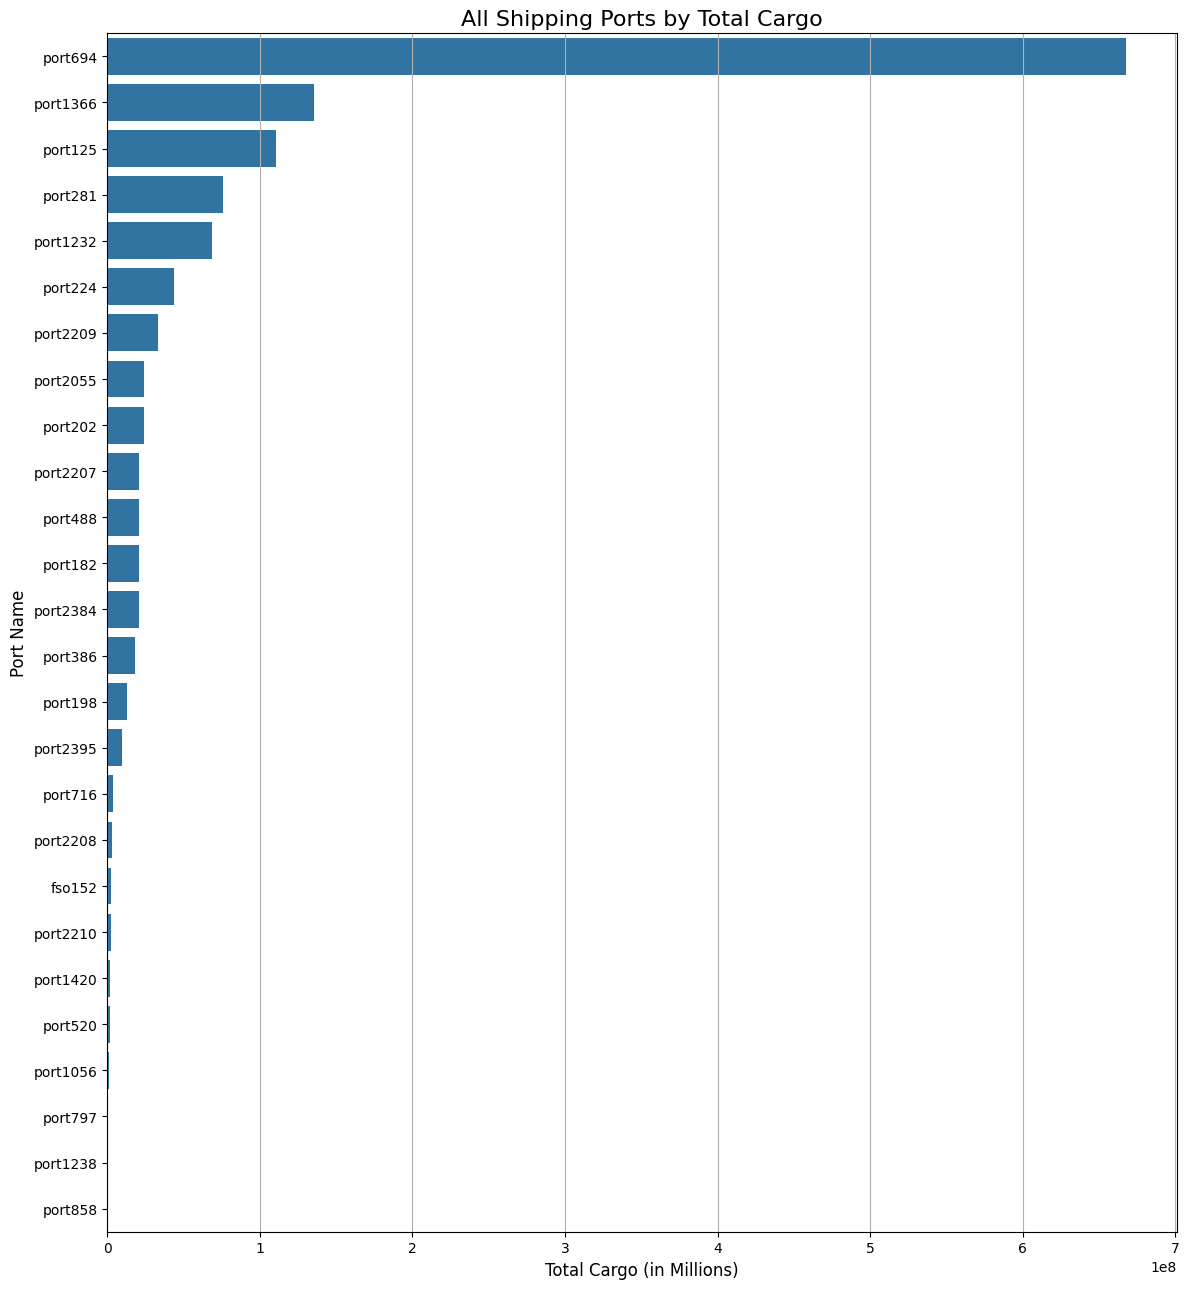

In [10]:
import seaborn as sns
# Calculate total cargo for each port
port_traffic = df.groupby('portid')[['import', 'export']].sum().reset_index()
port_traffic['total_cargo'] = port_traffic['import'] + port_traffic['export']

# Sort all ports by total cargo for better visualization
all_ports_traffic = port_traffic.sort_values(by='total_cargo', ascending=False)

fig_height = max(6, 26 * 0.5)

plt.figure(figsize=(12, fig_height))
sns.barplot(x = 'total_cargo', y = 'portid', data=all_ports_traffic)
plt.title('All Shipping Ports by Total Cargo', fontsize = 16)
plt.xlabel('Total Cargo (in Millions)', fontsize = 12)
plt.ylabel('Port Name', fontsize=12)
plt.grid(axis='x')
plt.tight_layout()
plt.show()

Nutshell Plot

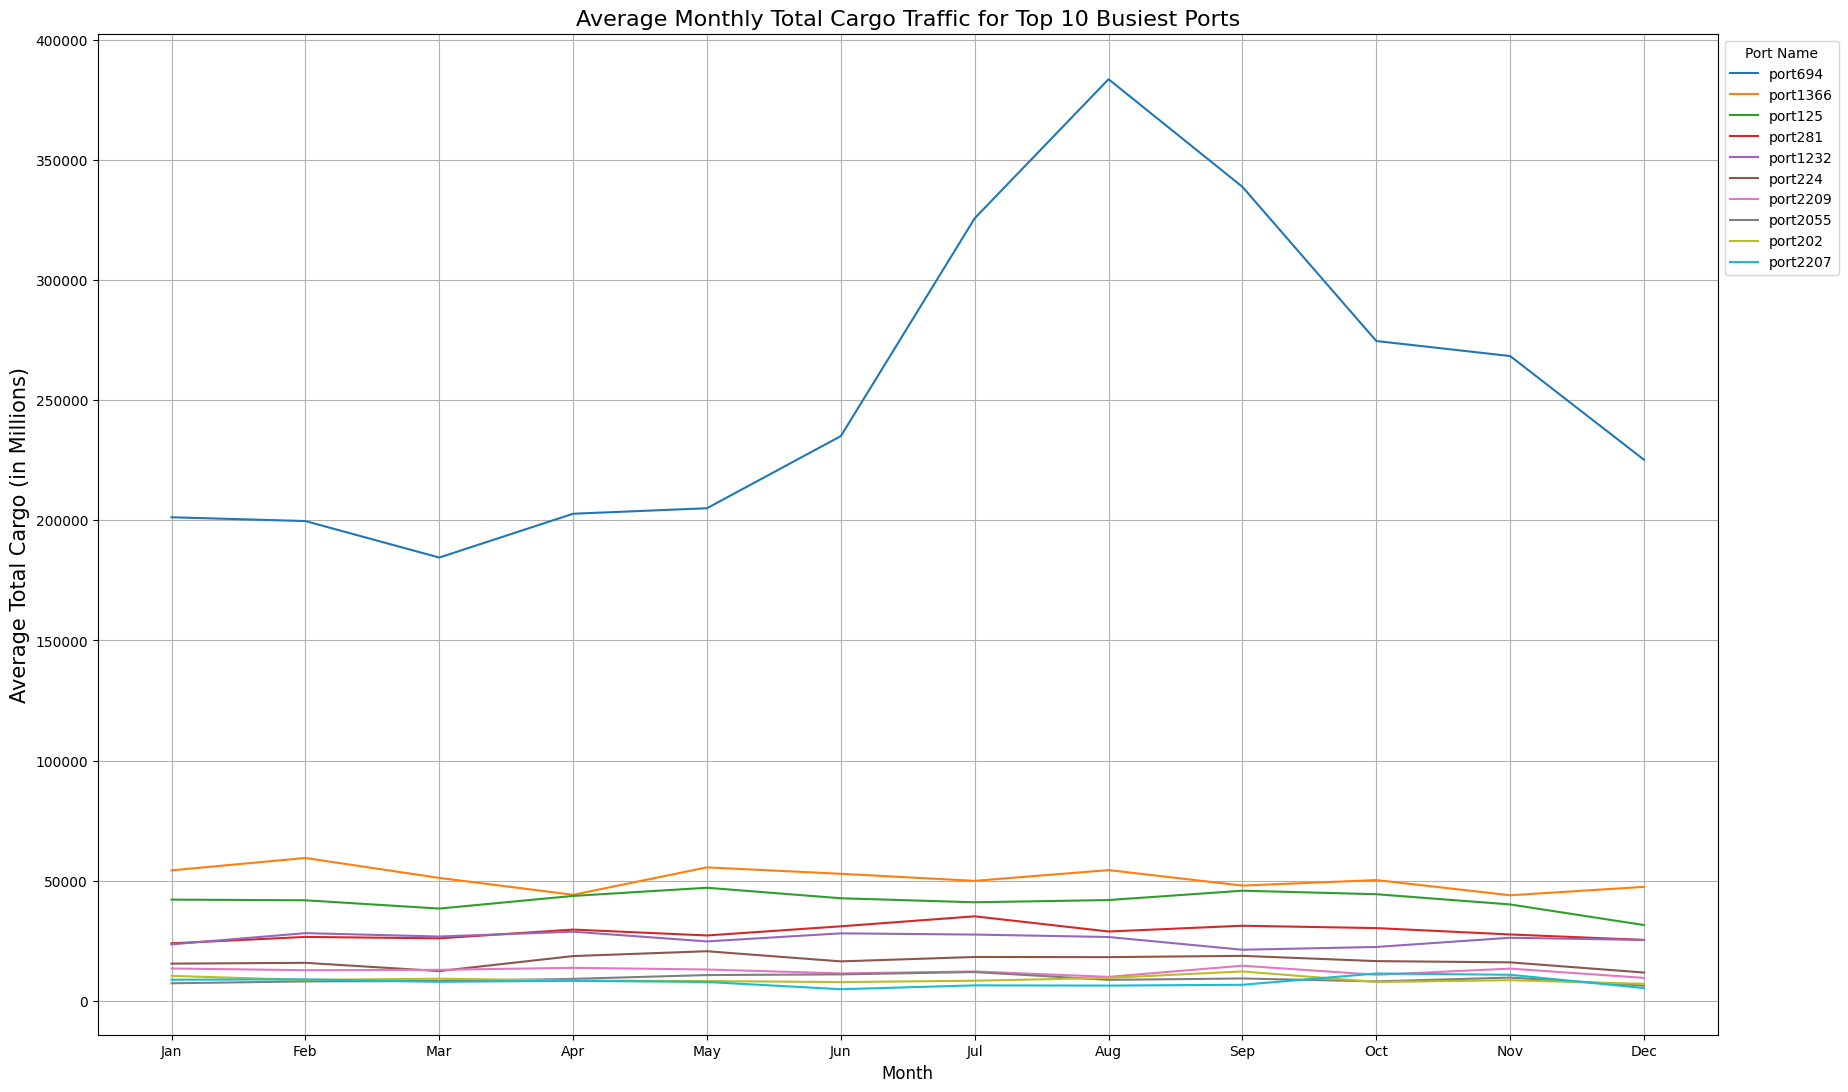

In [11]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# Calculate monthly average cargo for all individual ports
monthly_individual = df.groupby(['portid', 'month'])[['import', 'export']].mean().reset_index()
monthly_individual['total_cargo'] = monthly_individual['import'] + monthly_individual['export']

# Calculate total cargo per port (sum of monthly averages) to find the top 10
port_total_cargo = monthly_individual.groupby('portid')['total_cargo'].sum().reset_index()
top_10_port_names = port_total_cargo.nlargest(10, 'total_cargo')['portid'].tolist()
top_10_ports_monthly_traffic = monthly_individual[monthly_individual['portid'].isin(top_10_port_names)]

plt.figure(figsize = (20.9, 13))

# Plot the top 10 ports on a single graph
for port in top_10_port_names :
    port_data = top_10_ports_monthly_traffic[top_10_ports_monthly_traffic['portid'] == port]
    plt.plot(port_data['month'], port_data['total_cargo'], label = port)

plt.title('Average Monthly Total Cargo Traffic for Top 10 Busiest Ports', fontsize = 16)
plt.xlabel('Month', fontsize = 12)
plt.ylabel('Average Total Cargo (in Millions)', fontsize = 15)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Port Name', bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True)
plt.show()

In [12]:
# Hypothesis Testing: Kruskal-Wallis Test to compare monthly port activity

df['total_cargo'] = df['import'] + df['export']
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

monthly_port_cargo = df.groupby(['month', 'portid'])['total_cargo'].sum().reset_index()

monthly_cargo_data = []
for month in sorted(df['month'].unique()) :
    cargo_for_month = monthly_port_cargo[monthly_port_cargo['month'] == month]['total_cargo'].values
    if len(cargo_for_month) > 0 :
        monthly_cargo_data.append(cargo_for_month)

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*monthly_cargo_data)

print(f"Kruskal-Wallis H-statistic: {h_statistic}")
print(f"P-value: {p_value}")

Kruskal-Wallis H-statistic: 0.6929718555244838
P-value: 0.9999923759484605


In [13]:
# Hypothesis Testing: Kruskal-Wallis Test to get variance of total cargo from different ports
port_cargo_data = []
for port in sorted(df['portid'].unique()) :
    # Get total_cargo for the current port across all months
    cargo_for_port = monthly_port_cargo[monthly_port_cargo['portid'] == port]['total_cargo'].values
    if len(cargo_for_port) > 0 :
        port_cargo_data.append(cargo_for_port)

# Perform Kruskal-Wallis H-test for ports
h_statistic_ports, p_value_ports = kruskal(*port_cargo_data)

print(f"Kruskal-Wallis H-statistic for Ports: {h_statistic_ports}")
print(f"P-value for Ports: {p_value_ports}")

Kruskal-Wallis H-statistic for Ports: 301.07769935869754
P-value for Ports: 3.654276670248012e-49


Discussion
The Kruskal-Wallis test for Monthly Port Activity produced an H-statistic of  0.6930  and p-value of  0.9999 . Since the p-value is greater than the significance level,  0.05 , there is no significant difference in port activity across the months. Hence, the hypothesis that December is the busiest month for ports is not supported by the results and is rejected.

Moreover, the Kruskal-Wallis test for total cargo across different ports resulted in an H-statistic of  300.0777  and a p-value of  3.6543∗10−49 . Since the p-value is vastly less than  0.05  and even very close to  0 , there is a highly significant difference in total cargo activity across different ports. Therefore, the hypothesis that Manila Port is the busiest port is supported by the results and is not rejected.

To relate this to the visual results, where August is the busiest month for ports, this suggests that any increased activity in August is not universal, and not enough to make it stand out from the rest when grouped by month. Instead this may be due to the significantly greater volume of cargo from Manila Port that caused the total monthly cargo across all ports to be greatest in August.